# Data visualization: best practices

After understanding how visualizations work, it is relevant for us to understand the best practices that should take place in any kind of data visualization. We will study color maps, data clarity, and more.

For example, what are misleading techniques in data visualization?

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/01-DataScience"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

import ml4mat_ucla as m4m
from ml4mat_ucla.cmap import plot_color_gradients

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

df = pd.read_csv(f"{ROOT}/data/ptable.csv")

## Color maps

Making an appropriate choice of color maps is required to produce useful scientific visualizations in general. Color maps should always be used appropriately to avoid deceiving or confusing the reader. The choice of color can also convey meaning, and should be decided carefully depending on the intended message.

Usually, the following colormap types are available:

- **Sequential**: Best for data that is sequential or continuous.
- **Diverging**: Best for data that is contrastive in nature.
- **Qualitative**: Best for data that is expressed in categories (i.e., no relationship between the data points)
- **Cyclic**: Used in very specific cases where data is cyclic (e.g., angle, time of the day)

Let us explore a few examples of color maps

### Sequential color maps

Sequential color maps are used when the data varies continuously, such as an intensity. Often, the information is encoded in multiple ways: hue, saturation, and brightness (value). Many times, complementary encoding helps reinforce the information to the reader compared to the use of a single encoding. Notice how the colors go from dark to bright, and that the choice of the color is useful in this case.

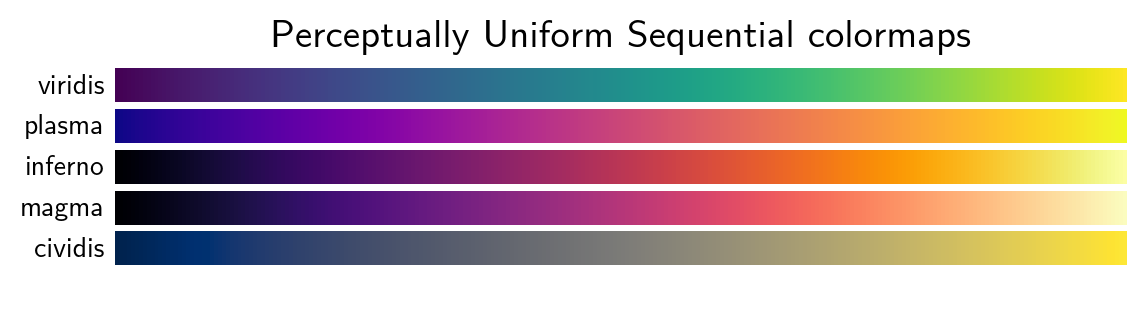

In [3]:
plot_color_gradients(
    'Perceptually Uniform Sequential',
    ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
)

The default colormaps above from `matplotlib` are the most recommended for plotting any kind of sequential data. However, many other choices exist:

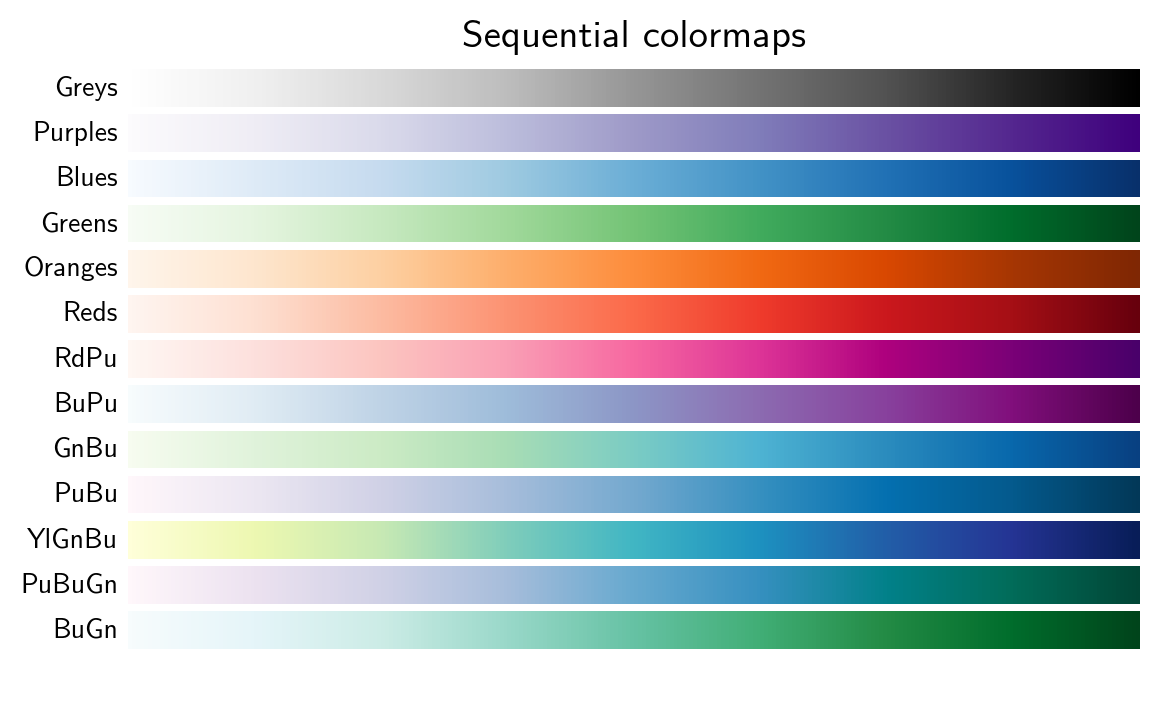

In [4]:
plot_color_gradients(
    'Sequential',
     ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
      'RdPu', 'BuPu',
      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn']
)

For example, how can we use sequential colormaps for conveying information about the variables?

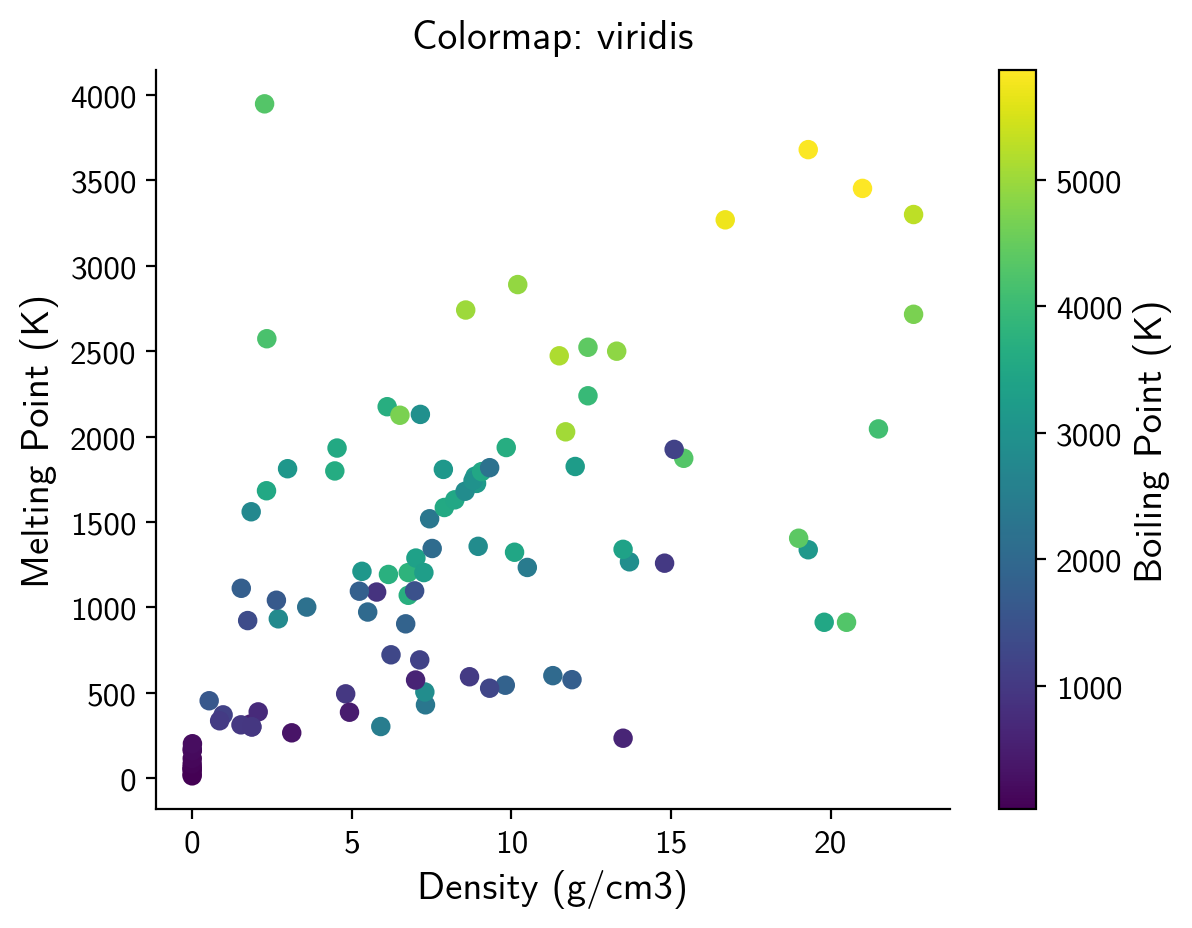

In [14]:
fig, ax = plt.subplots()

cmap = "viridis"

sc = ax.scatter(
    df["Density"],
    df["MeltingPoint"],
    c=df["BoilingPoint"],
    cmap=cmap,
)

ax.set_xlabel("Density (g/cm3)")
ax.set_ylabel("Melting Point (K)")

cbar = fig.colorbar(sc)
cbar.set_label("Boiling Point (K)")

ax.set_title(f"Colormap: {cmap}")

plt.show()

Notice how the continuous variation of boiling point and density leads to a graph that conveys a sense of correlation between the three variables.

### Diverging color maps

Diverging color maps are used when the data varies in two main classes that are mutually exclusive (e.g., positive and negative), and have a meaningful middle point (e.g., zero). They vary continously, but not towards a single direction. Rather, diverging color maps show extremes in the data.

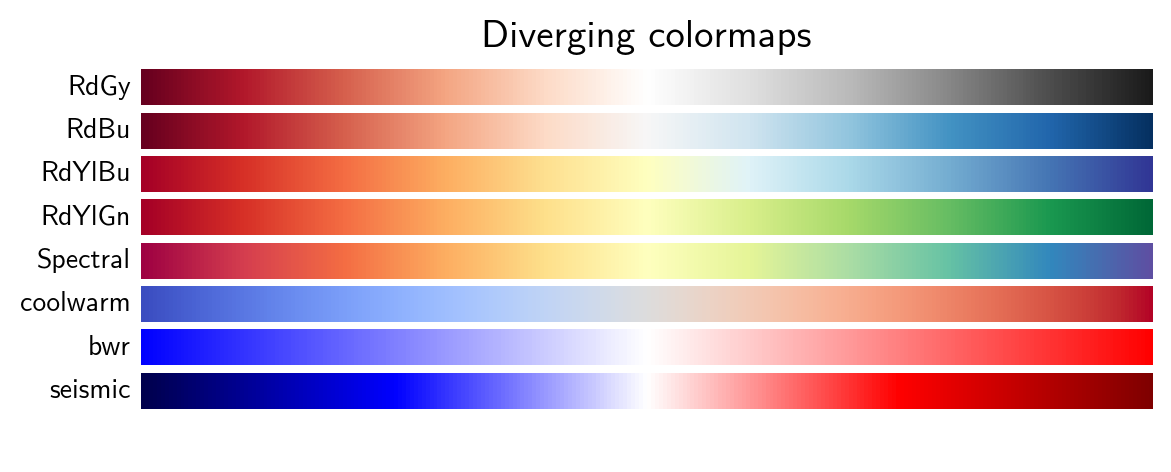

In [6]:
plot_color_gradients('Diverging',
                     ['RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic'])

Example: using a diverging color scheme to contrast between metals and non-metals.

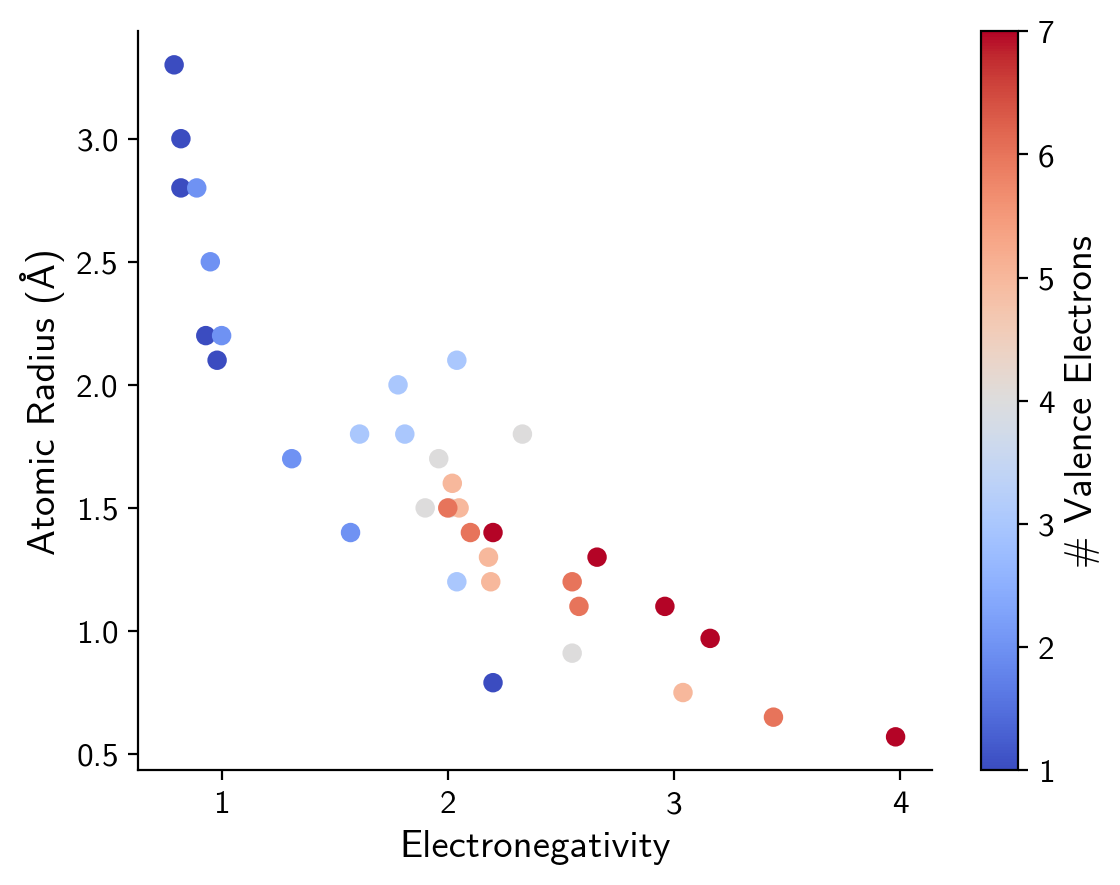

In [15]:
fig, ax = plt.subplots()

norm = plt.Normalize(1, 8)
cmap = lambda x: cm.coolwarm(norm(x))

colors = np.array([cmap(x) for x in df["NumberofValence"]])

sc = ax.scatter(
    df["Electronegativity"],
    df["AtomicRadius"],
    c=df["NumberofValence"],
    cmap="coolwarm",
)

cbar = fig.colorbar(sc)
cbar.set_label("# Valence Electrons")

ax.set_xlabel("Electronegativity")
ax.set_ylabel("Atomic Radius (Å)")

plt.show()

In the plot above, colors shifted towards red indicate more non-metallic behavior, and colors shifted towards blue indicate more metallic behavior. The middle point (4 electrons) is known to be common with covalently bonded systems.

### Categorical color maps

Categorical color maps are used when the data varies in multiple classes. Often, the relationship between these classes cannot be expressed by relationships in colors. 

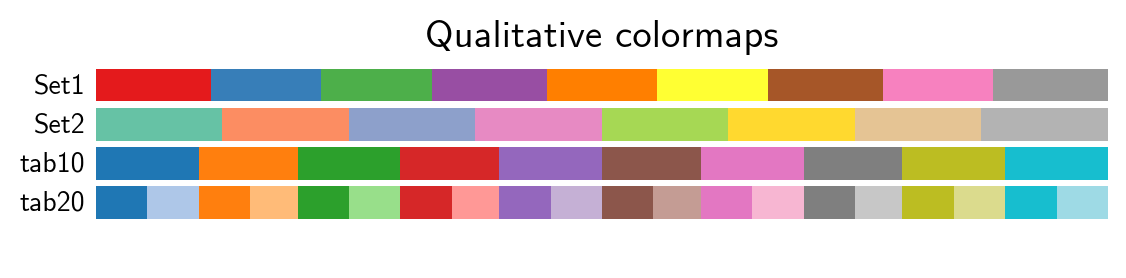

In [8]:
plot_color_gradients('Qualitative',
 ['Set1', 'Set2', 'tab10', 'tab20']
)

We have used this colormap in the past, for instance, to distinguish between metals, non-metals etc.

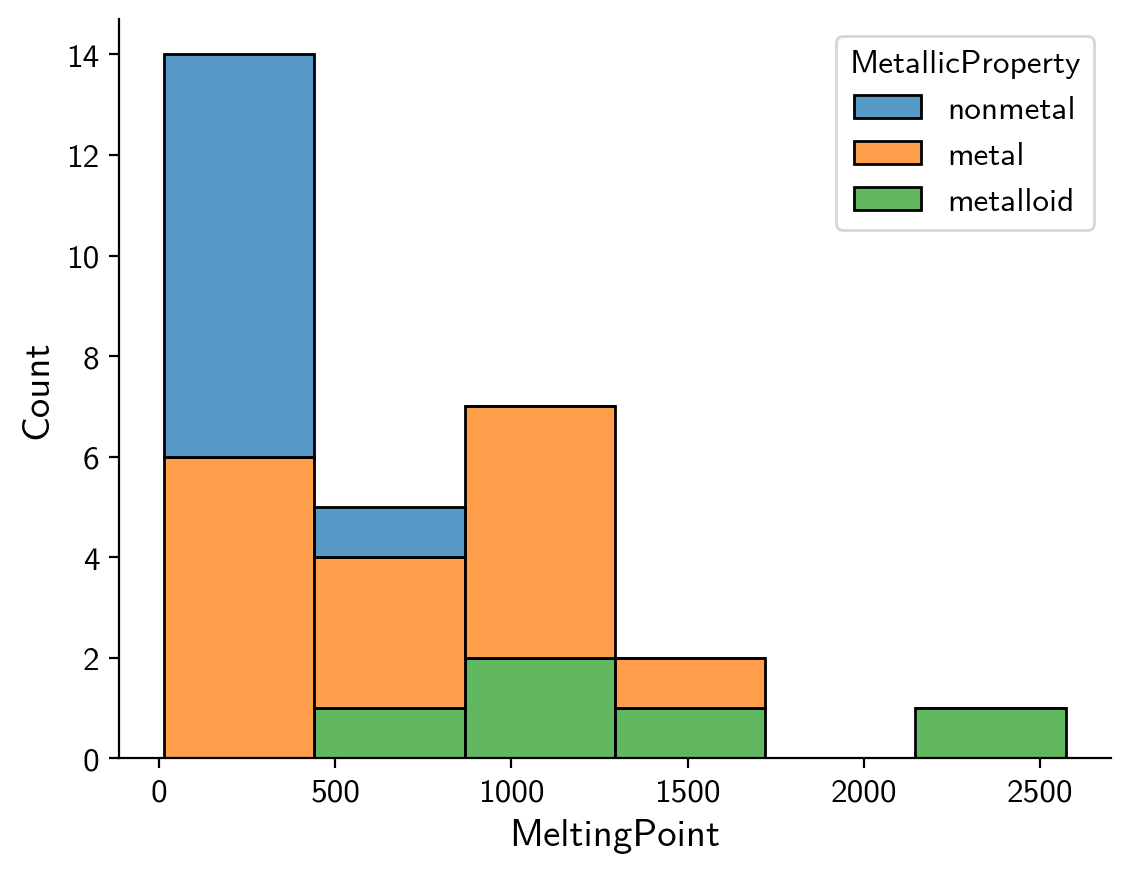

In [9]:
sns.histplot(data=df.dropna(), x='MeltingPoint', hue='MetallicProperty', multiple='stack')

plt.show()

### Cyclic colormaps

These colormaps are useful when the notion of periodicity is well-defined. For instance, in EBSD images, where the phase corresponds to the crystal orientation, it is useful to rely on cyclic colormaps such as `hsv`:

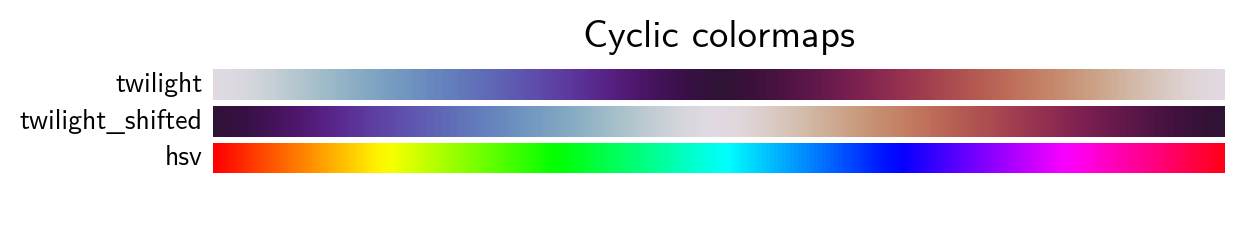

In [10]:
plot_color_gradients('Cyclic', ['twilight', 'twilight_shifted', 'hsv'])

Nevertheless, one has to understand that the `hsv` color map has several spots where the brightness may be misleading. The same is valid for other colormaps.

## Markers

The choice of markers can be really important when plotting data. Inadequate choice of markers can lead to misleading or confusing data.

For instance, using markers when plotting categorical data is not necessarily the most clear approach:

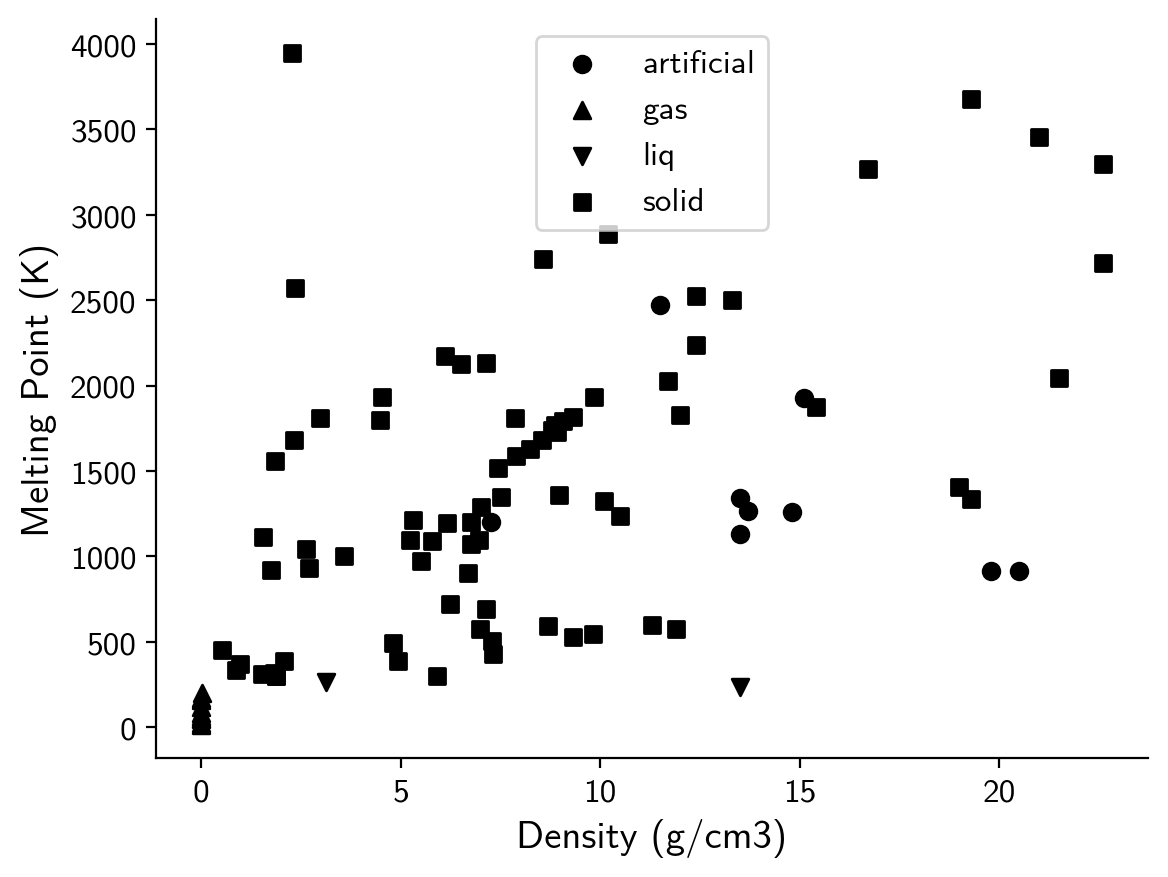

In [11]:
fig, ax = plt.subplots()

markers = ["o", "^", "v", "s"]

for (label, grp), m in zip(df.groupby("Phase"), markers):
    ax.scatter(
        grp["Density"],
        grp["MeltingPoint"],
        color="k",
        marker=m,
        label=label,
    )

ax.set_xlabel("Density (g/cm3)")
ax.set_ylabel("Melting Point (K)")

ax.legend()
plt.show()

Markers with different areas can also be somewhat misleading in terms of visibility. Therefore, if you are going to use markers, it is suggested that you use them to reinforce information that already exists represented in colors or other encoding types.

## Chart junk

"Chart junk" is everything that does not contribute to the successful visualization of the information. Often, you will be faced by a range of plots that demonstrate unclear information, or too much information, because of its formatting choices.

The following GIF is one example on the difference that the visualization makes on the final figure.

![image](http://static1.squarespace.com/static/56713bf4dc5cb41142f28d1f/5671e8bf816924fc22651410/5671eae2816924fc2265189a/1450306274301/data-ink.gif)

When plotting your data, make sure that you follow these best practices and avoid chart junk!